# Complementary slackness contacts

This notebook generates `fig:dual-complementary-slackness-contacts`.  For the one-dimensional quadratic cost
$$
    c(x,y)=|x-y|^2,
$$
optimal dual potentials satisfy
$$
    f(x)+g(y) \leq c(x,y),
$$
and complementary slackness says that an optimal plan can charge only the contact set where equality holds.  In one dimension, the optimal plan is the graph of the monotone rearrangement
$$
    T = F_\beta^{-1}\circ F_\alpha.
$$
The figure plots the nonnegative slack
$$
    s(x,y)=c(x,y)-f(x)-g(y)
$$
as a continuous heatmap and highlights the transported contacts $(x,T(x))$ in violet.

In [1]:
from pathlib import Path
import os
import shutil
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate figure_style.py")

sys.path.insert(0, str(FIGROOT.resolve()))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image as DisplayImage
from IPython.display import display
from matplotlib import patheffects as pe
from matplotlib.colors import LinearSegmentedColormap

from figure_style import (
    BACKGROUND,
    BLUE,
    GRAY,
    RED,
    VIOLET,
    box_axes,
    figure_dir,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "dual-complementary-slackness-contacts"
OUT = figure_dir(NAME)
ARXIV_OUT = ROOT / "arxiv" / "figures"
THUMB_OUT = FIGROOT / "thumbnails"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)
THUMB_OUT.mkdir(parents=True, exist_ok=True)


## Smooth mixture data and exact monotone map

The densities are deliberately asymmetric Gaussian mixtures, so the contact graph is visibly curved rather than close to the diagonal.  The computation remains exact at the continuum level: the map is recovered from numerical quantiles, then the potential derivative
$$
    f'(x)=\partial_x c(x,T(x)) = 2(x-T(x))
$$
is integrated on a fine grid.  The second potential is the hard `c`-transform $g=f^c$, which enforces the dual feasibility inequality on the grid.  A final diagnostic evaluates the slack again along the quantile graph to check that the displayed violet curve is indeed a numerical contact set.


In [2]:
grid = np.linspace(-3.35, 3.35, 1000)
dx = grid[1] - grid[0]


def gaussian_mixture_density(x, weights, means, stds):
    x = np.asarray(x)
    density = np.zeros_like(x, dtype=float)
    for w, m, s in zip(weights, means, stds):
        density += w * np.exp(-0.5 * ((x - m) / s) ** 2) / (s * np.sqrt(2 * np.pi))
    density /= np.trapezoid(density, x)
    return density


def cdf_from_density(density):
    increments = 0.5 * (density[:-1] + density[1:]) * np.diff(grid)
    cdf = np.r_[0.0, np.cumsum(increments)]
    cdf /= cdf[-1]
    # Numerical monotonicity protects the inverse interpolation in the far tails.
    return np.maximum.accumulate(cdf)


def cumulative_trapezoid(values):
    increments = 0.5 * (values[:-1] + values[1:]) * np.diff(grid)
    return np.r_[0.0, np.cumsum(increments)]


alpha = gaussian_mixture_density(
    grid,
    weights=[0.38, 0.35, 0.27],
    means=[-1.75, -0.30, 1.00],
    stds=[0.26, 0.45, 0.30],
)
beta = gaussian_mixture_density(
    grid,
    weights=[0.24, 0.48, 0.28],
    means=[-0.95, 0.55, 1.95],
    stds=[0.32, 0.34, 0.23],
)

Fa = cdf_from_density(alpha)
Fb = cdf_from_density(beta)
levels = np.clip(Fa, 2e-5, 1 - 2e-5)
T = np.interp(levels, Fb, grid)

fp = 2.0 * (grid - T)
f = cumulative_trapezoid(fp)
f -= np.trapezoid(f * alpha, grid)

C = (grid[:, None] - grid[None, :]) ** 2
g = np.min(C - f[:, None], axis=0)

slack = C - f[:, None] - g[None, :]
slack_display = np.maximum(slack, 0.0)

beta_T = np.interp(T, grid, beta)
contact_mask = (
    (alpha > 0.018 * alpha.max())
    & (beta_T > 0.018 * beta.max())
    & (T > grid.min() + 0.06)
    & (T < grid.max() - 0.06)
)
contact_residual = (grid - T) ** 2 - f - np.interp(T, grid, g)
print(f"minimum grid slack = {slack.min():.3e}")
print(f"median |slack| on drawn contact graph = {np.median(np.abs(contact_residual[contact_mask])):.3e}")
print(f"max |slack| on drawn contact graph = {np.max(np.abs(contact_residual[contact_mask])):.3e}")


minimum grid slack = 0.000e+00
median |slack| on drawn contact graph = 2.606e-06
max |slack| on drawn contact graph = 5.019e-05


## Exported panel

The center image displays $s(x,y)$.  Darker blue means a larger strict slack in the dual inequality, while the pale valley is the near-zero contact locus.  The violet curve and dots mark the contact set associated with the monotone transport map.  The red and blue marginal strips identify which one-dimensional mixtures are being transported.


In [3]:
slack_cmap = LinearSegmentedColormap.from_list(
    "ot4ml_slack",
    ["#fffaf0", "#efe4f0", "#ccdff1", "#80a7cf", "#234b82"],
)

xlim = (-2.65, 2.75)
ylim = (-1.65, 2.50)
x_visible = (grid >= xlim[0]) & (grid <= xlim[1])
y_visible = (grid >= ylim[0]) & (grid <= ylim[1])
visible_slack = slack_display[np.ix_(x_visible, y_visible)]
positive_visible = visible_slack[visible_slack > 1e-8]

# Clamp on the displayed window, not the far-away tails, so the contact valley
# stays visible while the largest slack region remains saturated.
vmax = np.quantile(visible_slack, 0.91)
contour_levels = np.quantile(positive_visible, [0.025, 0.075, 0.16, 0.31, 0.52, 0.76])

fig = plt.figure(figsize=(3.62, 3.23))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.0, 0.16],
    height_ratios=[0.17, 1.0],
    wspace=0.034,
    hspace=0.034,
)
ax_top = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

ax.imshow(
    np.clip(slack_display.T, 0.0, vmax),
    origin="lower",
    extent=[grid.min(), grid.max(), grid.min(), grid.max()],
    cmap=slack_cmap,
    vmin=0.0,
    vmax=vmax,
    interpolation="bilinear",
    aspect="auto",
)
ax.contour(
    grid,
    grid,
    slack_display.T,
    levels=contour_levels,
    colors="#334155",
    linewidths=0.28,
    alpha=0.34,
)

# A white halo makes the contact line readable on both pale and blue regions.
halo = [pe.Stroke(linewidth=3.05, foreground="white", alpha=0.92), pe.Normal()]
ax.plot(
    grid[contact_mask],
    T[contact_mask],
    color=VIOLET,
    lw=1.65,
    solid_capstyle="round",
    path_effects=halo,
    zorder=5,
)
q = np.linspace(0.055, 0.945, 19)
xq = np.interp(q, Fa, grid)
yq = np.interp(q, Fb, grid)
ax.scatter(xq, yq, s=11.5, color=VIOLET, edgecolor="white", linewidth=0.42, zorder=6)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$x$", labelpad=1.0)
ax.set_ylabel(r"$y$", labelpad=1.0)
ax.tick_params(labelbottom=False, labelleft=False, length=0)
box_axes(ax)

ax_top.fill_between(grid, 0, alpha, color=RED, alpha=0.25, linewidth=0)
ax_top.plot(grid, alpha, color=RED, lw=0.86)
ax_top.set_xlim(*xlim)
ax_top.set_ylim(0, 1.08 * alpha[x_visible].max())
ax_top.tick_params(labelbottom=False, labelleft=False, length=0)
ax_top.set_facecolor(BACKGROUND)
box_axes(ax_top)

ax_right.fill_betweenx(grid, 0, beta, color=BLUE, alpha=0.25, linewidth=0)
ax_right.plot(beta, grid, color=BLUE, lw=0.86)
ax_right.set_ylim(*ylim)
ax_right.set_xlim(0, 1.08 * beta[y_visible].max())
ax_right.tick_params(labelbottom=False, labelleft=False, length=0)
ax_right.set_facecolor(BACKGROUND)
box_axes(ax_right)

save_pdf(fig, OUT / "contacts.pdf", pad_inches=0.028)
fig.savefig(THUMB_OUT / f"{NAME}.png", dpi=220, bbox_inches="tight", pad_inches=0.022)
plt.close(fig)

shutil.copyfile(OUT / "contacts.pdf", ARXIV_OUT / f"{NAME}--contacts.pdf")
print(f"Wrote {OUT / 'contacts.pdf'}")
print(f"Wrote {ARXIV_OUT / (NAME + '--contacts.pdf')}")
print(f"Wrote {THUMB_OUT / (NAME + '.png')}")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Wrote /Users/gpeyre/Dropbox/github/ot4ml/latex/figures/dual-complementary-slackness-contacts/contacts.pdf
Wrote /Users/gpeyre/Dropbox/github/ot4ml/arxiv/figures/dual-complementary-slackness-contacts--contacts.pdf
Wrote /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/dual-complementary-slackness-contacts.png


## Gallery preview

The PDF used in the book is title-free.  The PNG below is the notebook-gallery thumbnail regenerated from the same drawing code.

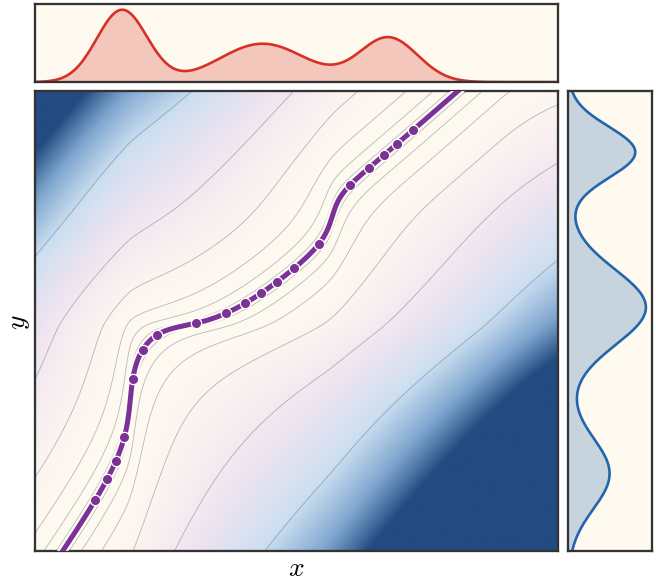

In [4]:
display(DisplayImage(filename=str(THUMB_OUT / f"{NAME}.png"), width=520))
